# Experiments notebook

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.ML.config import FULL_FEATURES, RANDOM_STATE, TEST_SIZE, CV_FOLDS
from src.ML.pipelines import create_LR_pipeline, create_RF_pipeline, create_SVR_pipeline
from src.ML.evaluation import train_and_evaluate
from src.ML.visualization import *
from src.ML.tunning import tune_RF, tune_SVR
from sklearn.decomposition import PCA



## Load data/Generate random data

In [2]:
from sklearn.model_selection import train_test_split


def make_random_data(n_samples=200):
    X=pd.DataFrame(
        np.random.randn(n_samples,len(FULL_FEATURES)),
                        columns=FULL_FEATURES
    )
    y=np.random.uniform(0,10,n_samples)
    return X,y

x,y=make_random_data()
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

## PCA?


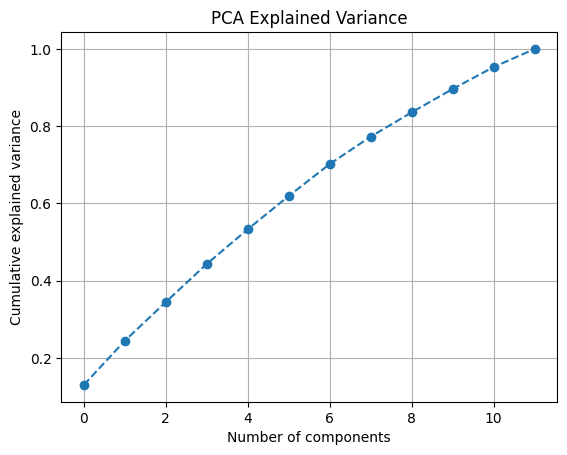

In [3]:
pca = PCA()
pca.fit(X_train)

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    linestyle='--',   
    marker='o'        #
)

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.grid(True)

plt.show()

## Run model (baseline)


In [4]:
pipeline_lr=create_LR_pipeline()
pipeline_rf=create_RF_pipeline()
pipeline_svr=create_SVR_pipeline()

metrics_lr,y_pred_lr=train_and_evaluate(pipeline_lr, X_train, y_train, X_test, y_test)
metrics_rf,y_pred_rf=train_and_evaluate(pipeline_rf, X_train, y_train, X_test, y_test)
metrics_svr,y_pred_svr=train_and_evaluate(pipeline_svr, X_train, y_train, X_test, y_test)
print("LR Metrics:", metrics_lr)
print("RF Metrics:", metrics_rf)
print("SVR Metrics:", metrics_svr)

LR Metrics: {'MSE': 10.803548283954282, 'R2': -0.2037059469911069, 'MAE': 2.793722395467354}
RF Metrics: {'MSE': 9.451617132456391, 'R2': -0.05307695693998671, 'MAE': 2.5482503924175894}
SVR Metrics: {'MSE': 10.013604507392188, 'R2': -0.1156922688323625, 'MAE': 2.6994844849537207}


In [5]:
results = []
results.append({"Model": "Linear Regression", **metrics_lr})
results.append({"Model": "Random Forest", **metrics_rf})
results.append({"Model": "SVR", **metrics_svr})

results_df = pd.DataFrame(results)
results_df

,Model,MSE,R2,MAE
0,Linear Regression,10.803548,-0.203706,2.793722
1,Random Forest,9.451617,-0.053077,2.548250
2,SVR,10.013605,-0.115692,2.699484


## PLOTS

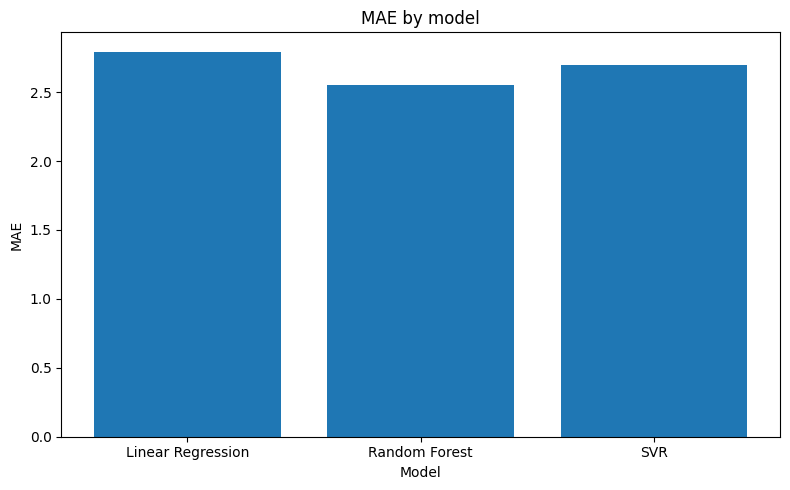

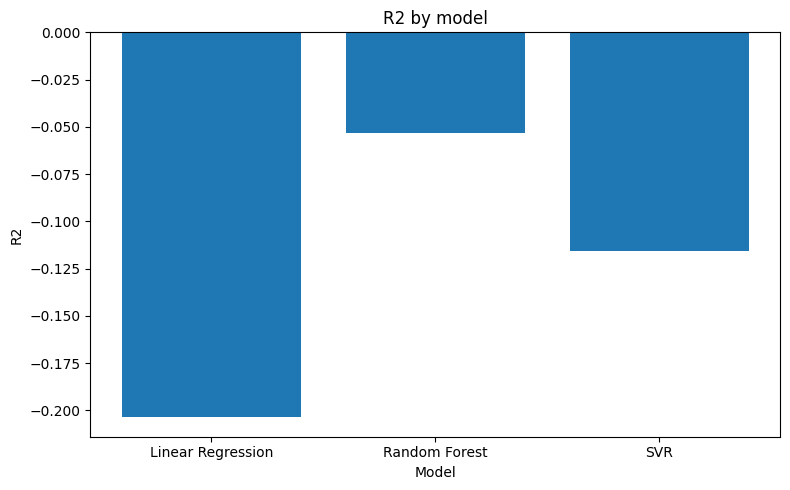

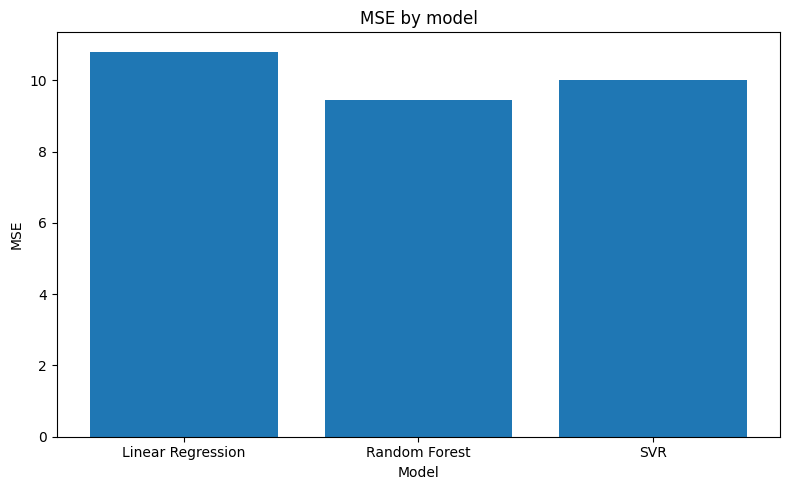

In [6]:
plot_metric_by_model(results_df, metric="MAE")
plot_metric_by_model(results_df, metric="R2")
plot_metric_by_model(results_df, metric="MSE")

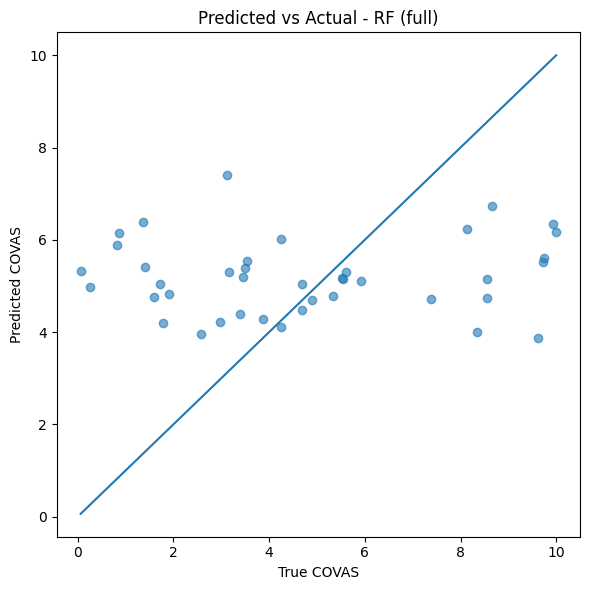

In [7]:
plot_predicted_vs_actual(y_test, y_pred_rf, model_name="RF", feature_set="full")

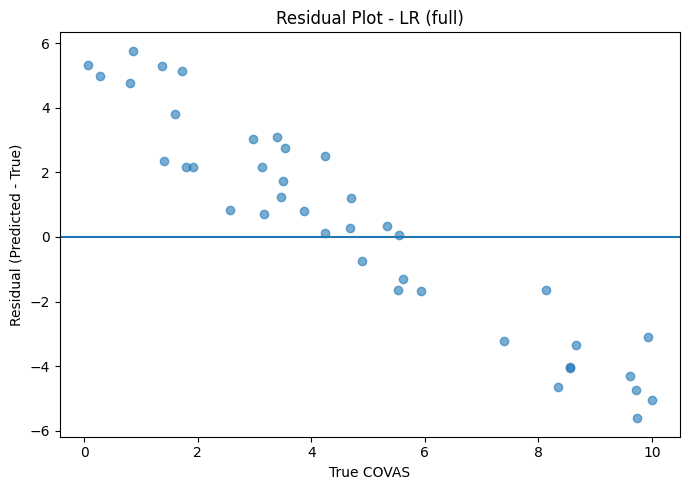

In [8]:
plot_residuals(y_test, y_pred_lr, model_name="LR", feature_set="full")

### LINEAR REGRESSION ASSUMPTIONS

1. Residues follow a **normal distribution**
2. Residues have **zero mean** and **constant variance**
3. Residues are **independent** (aka no real structure)
4. **Linearity**  (check resiudals vs fitted values)

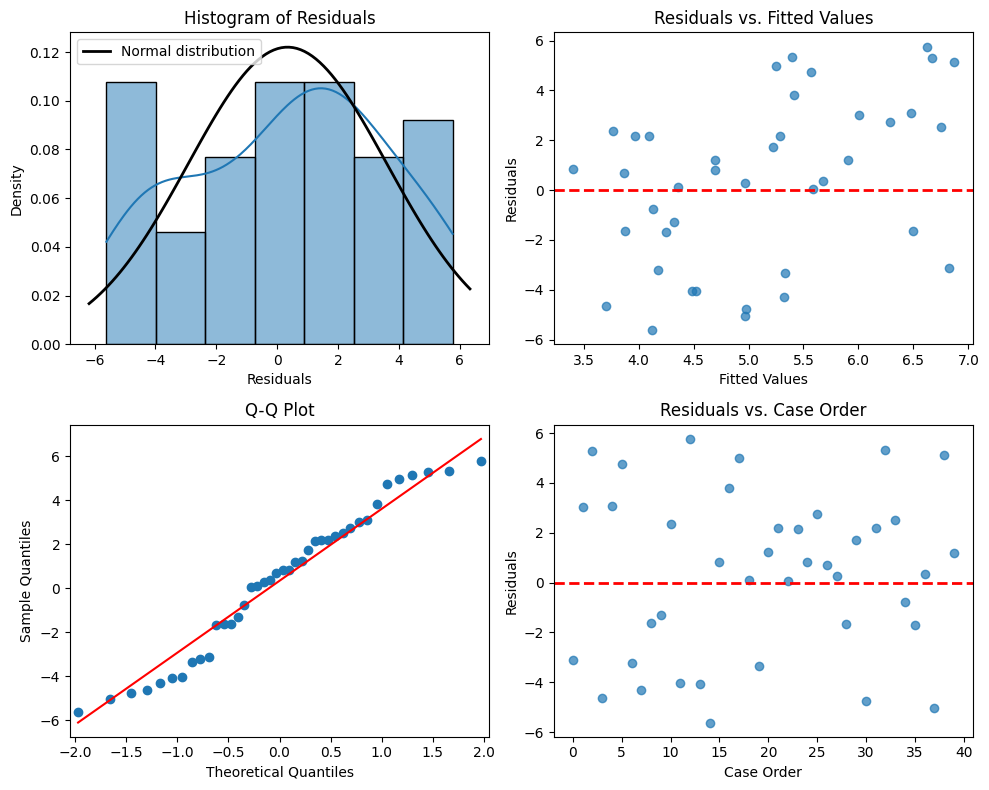

In [9]:
residual_analysis(y_test, y_pred_lr)

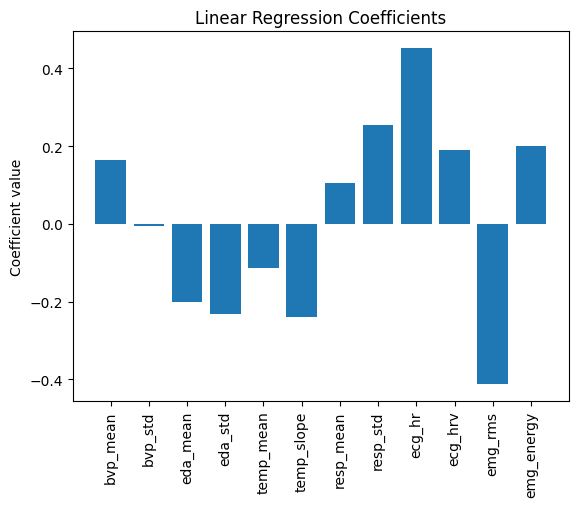

In [10]:
plot_lr_coefficients(pipeline_lr, feature_names=FULL_FEATURES)

### SVR tunnnig


In [11]:
grid_svr = tune_SVR(X_train, y_train)
print(grid_svr.best_params_)
best_svr = grid_svr.best_estimator_
print(grid_svr.best_score_)


{'model__C': 1, 'model__degree': 2, 'model__epsilon': 0.5, 'model__gamma': 'scale', 'model__kernel': 'poly'}
-2.482877752779897


In [12]:
metrics_best_svr,y_pred_best_svr=train_and_evaluate(best_svr, X_train, y_train, X_test, y_test)
print("Tuned SVR Metrics:", metrics_best_svr)

Tuned SVR Metrics: {'MSE': 11.138120723961325, 'R2': -0.2409832215633827, 'MAE': 2.797969396723711}


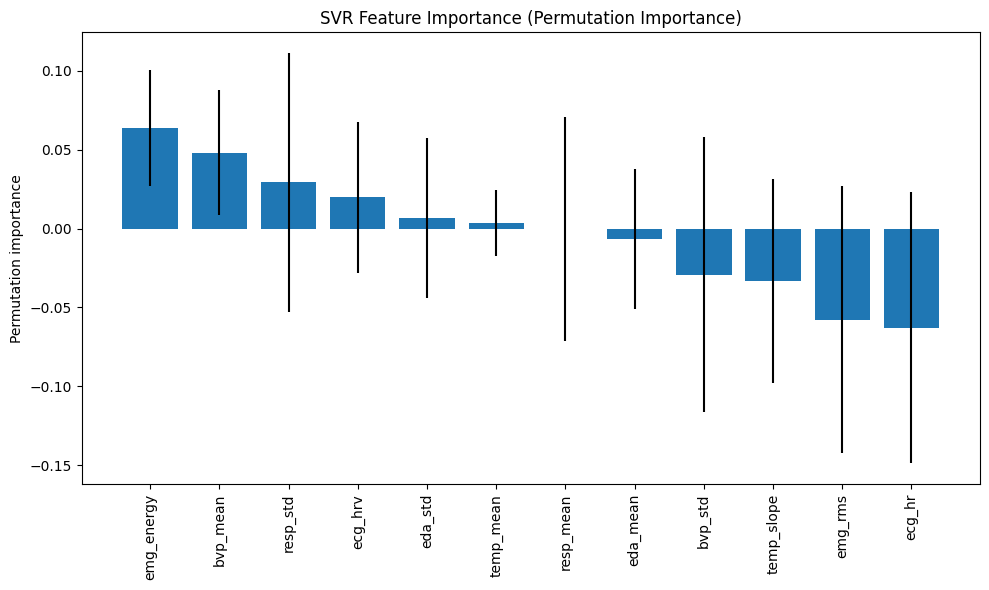

In [13]:
plot_svr_permutation_importance(
    best_svr,
    X_test,
    y_test,
    FULL_FEATURES
)

### Random Forest tunning

In [14]:
grid_rf = tune_RF(X_train, y_train)

print(grid_rf.best_params_)
best_rf = grid_rf.best_estimator_
print(grid_rf.best_score_)

{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 300}
-2.6064884124509584


In [15]:
metrics_best_rf,y_pred_best_rf=train_and_evaluate(best_rf, X_train, y_train, X_test, y_test)
print("Tuned RF Metrics:", metrics_best_rf)

Tuned RF Metrics: {'MSE': 9.162980229476938, 'R2': -0.020917711893293722, 'MAE': 2.5419006137693385}


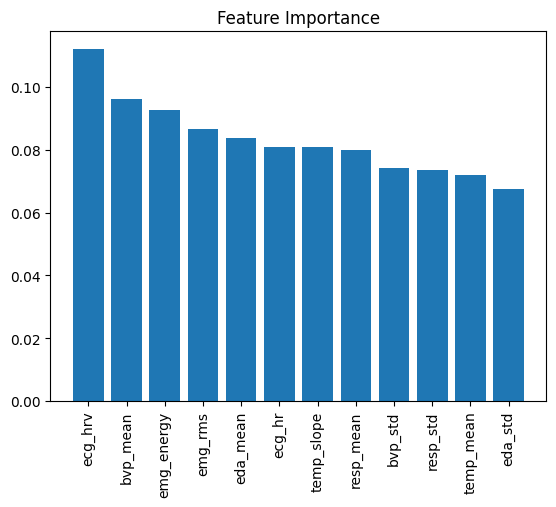

In [16]:
plot_feature_importance_rf(best_rf, feature_names=FULL_FEATURES)